# HCC1806 SmartSeq Unsupervised Analysis

# Introduction

This notebook applies unsupervised learning methods to the HCC1806 SMARTseq dataset. The goal is to investigate whether cells naturally group according to their biological condition (Hypoxia or Normoxia) without using labels, and to understand the structure of the data before moving to supervised classification.

The notebook is organised as follows. We begin by loading and preparing the filtered normalised training dataset. We then apply PCA to reduce dimensionality and visualise the data in 2D and 3D. Next we run K-Means and Agglomerative clustering on both the full dataset and the PCA reduced space, evaluating performance through clustering accuracy and confusion matrices. Finally we use UMAP to visualise the data in a non linear embedding and project the clustering results onto it to assess whether any meaningful structure reveals through unsupervised methods.

# 1. Libraries and Imports

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn scipy umap-learn
%pip install yellowbrick
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score, confusion_matrix, accuracy_score

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ranksums

import umap

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# 2. Loading and Preparing the Data

We load the filtered, normalised training dataset. The matrix is transposed so that rows represent cells and columns represent genes.

From the EDA we know that the dataset contains 97 Hypoxic and 85 Normoxic cells,corresponding to a 53%/47% split. The class imbalance is minimal and no resampling or reweighting is required.

The data is then standardised using StandardScaler so that each gene has mean 0 and standard deviation 1, which is essential for distance based methods like K-Means and PCA that are sensitive to feature magnitude.

In [ ]:
# Load data
data = pd.read_csv('/Users/Giuly/Documents/AI Lab/Dataset/SmartSeq/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt', delimiter=' ')

print("Original shape (genes x cells):", data.shape)
data.head()

Original shape (genes x cells): (3000, 182)


,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G7_Normoxia_S118_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G8_Normoxia_S19_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G9_Normoxia_S121_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1H1_Hypoxia_S103_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1H2_Hypoxia_S3_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
DDIT4,0,8739,13098,2880,7777,208,750,127,10313,13523,...,341,5545,5757,8337,2579,79,167,10186,238,60
ANGPTL4,48,2101,14032,356,5661,0,0,0,850,10110,...,10,2085,698,2383,65,5,1,3147,41,0
CALML5,0,55,0,0,4383,1902,0,0,0,0,...,0,1587,0,0,0,0,0,0,2867,0
KRT14,321,96,0,6211,0,0,5050,462,2127,0,...,0,0,3077,529,156,2098,27,149,814,7
CCNB1,298,1824,1616,3,145,378,66,58,605,1444,...,204,26,50,588,411,554,3585,1012,2207,477


In [4]:
# Transpose so rows = cells, columns = genes
data = data.T

print("Transposed shape (cells x genes):", data.shape)
data.head()

Transposed shape (cells x genes): (182, 3000)


,DDIT4,ANGPTL4,CALML5,KRT14,CCNB1,IGFBP3,AKR1C2,KRT6A,NDRG1,KRT4,...,MST1R,ZYG11A,NRG1,RBMS3,VCPIP1,LINC02693,OR8B9P,NEAT1,ZDHHC23,ODAD2
output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,0,48,0,321,298,82,6250,634,0,0,...,78,10,136,0,0,29,0,29,0,0
output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,8739,2101,55,96,1824,1938,62,0,522,413,...,279,0,264,0,134,68,0,213,0,0
output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,13098,14032,0,0,1616,247,430,907,348,0,...,311,0,38,0,0,0,0,92,0,0
output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,2880,356,0,6211,3,3430,79,1953,592,176,...,125,0,16,0,4,1,0,1,0,0
output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,7777,5661,4383,0,145,4618,246,85,206,0,...,268,1,25,0,0,0,0,128,0,0


In [7]:
# Scale the data
scaler = StandardScaler()
data = pd.DataFrame(scaler.fit_transform(data), index=data.index, columns=data.columns)

print("Scaled data shape:", data.shape)
print("Mean (should be ~0):", data.values.mean().round(6))
print("Std  (should be ~1):", data.values.std().round(6))

Scaled data shape: (182, 3000)
Mean (should be ~0): 0.0
Std  (should be ~1): 1.0


# 3. PCA

We apply Principal Component Analysis (PCA) to the scaled data. PCA reduces the dimensionality of the dataset while preserving as much variance as possible, making it easier to visualise and cluster high dimensional gene expression data. We first determine how many components are needed to explain 95% of the variance, then visualise the data in 2D and 3D to inspect whether any separation between Hypoxic and Normoxic cells is visible.

## Finding the right number of components

In [8]:
# Run PCA with 95% variance threshold
PCA_HCC = PCA(n_components=0.95)
data_HCC_red = PCA_HCC.fit_transform(data) 

print("Number of components:", PCA_HCC.n_components_)
print('Explained variation per principal component: {}'.format(PCA_HCC.explained_variance_ratio_))

Number of components: 157
Explained variation per principal component: [0.04164704 0.0277197  0.02652615 0.0205695  0.01987293 0.01892042
 0.01641928 0.01503244 0.01443172 0.01403566 0.01249199 0.01231298
 0.01161109 0.01140141 0.0108505  0.01025876 0.01000996 0.00986937
 0.00969219 0.00920771 0.00917151 0.00909787 0.00897551 0.00865642
 0.00858286 0.00820464 0.0080387  0.00795946 0.00784639 0.00774137
 0.00763508 0.00726468 0.00719362 0.00698828 0.00690921 0.0068647
 0.00676337 0.00662308 0.00650173 0.00640056 0.00632229 0.00621351
 0.00613067 0.00604838 0.00602104 0.00593816 0.0058311  0.00579162
 0.00576955 0.00571595 0.0056499  0.00561309 0.0055843  0.00549282
 0.0054893  0.00541348 0.00534951 0.00533334 0.00529679 0.00522703
 0.00519092 0.00510255 0.00506848 0.00501861 0.0050088  0.00495661
 0.00494039 0.00485677 0.00483    0.00481096 0.00476932 0.00473307
 0.00471231 0.00467061 0.00463369 0.00460893 0.00460725 0.00455079
 0.00453449 0.00452206 0.00446647 0.00445982 0.00438436 0.0

In [9]:
# Reconstruction error
from sklearn.metrics import mean_squared_error

print("Reconstruction error:", mean_squared_error(PCA_HCC.inverse_transform(data_HCC_red), data))

Reconstruction error: 0.04922096528729001


PCA requires 157 components to explain 95% of the variance in the HCC1806 SMARTseq dataset,with a reconstruction error of 0.049. Relative to the original 3,000 genes this is quite compact, as just 5% of the original dimensions is sufficient to capture most of the variance. The high number of components nonetheless reflects the biological complexity of the system since no single gene dominates the variance, which is expected given that cellular behaviour depends on a high number of genes.

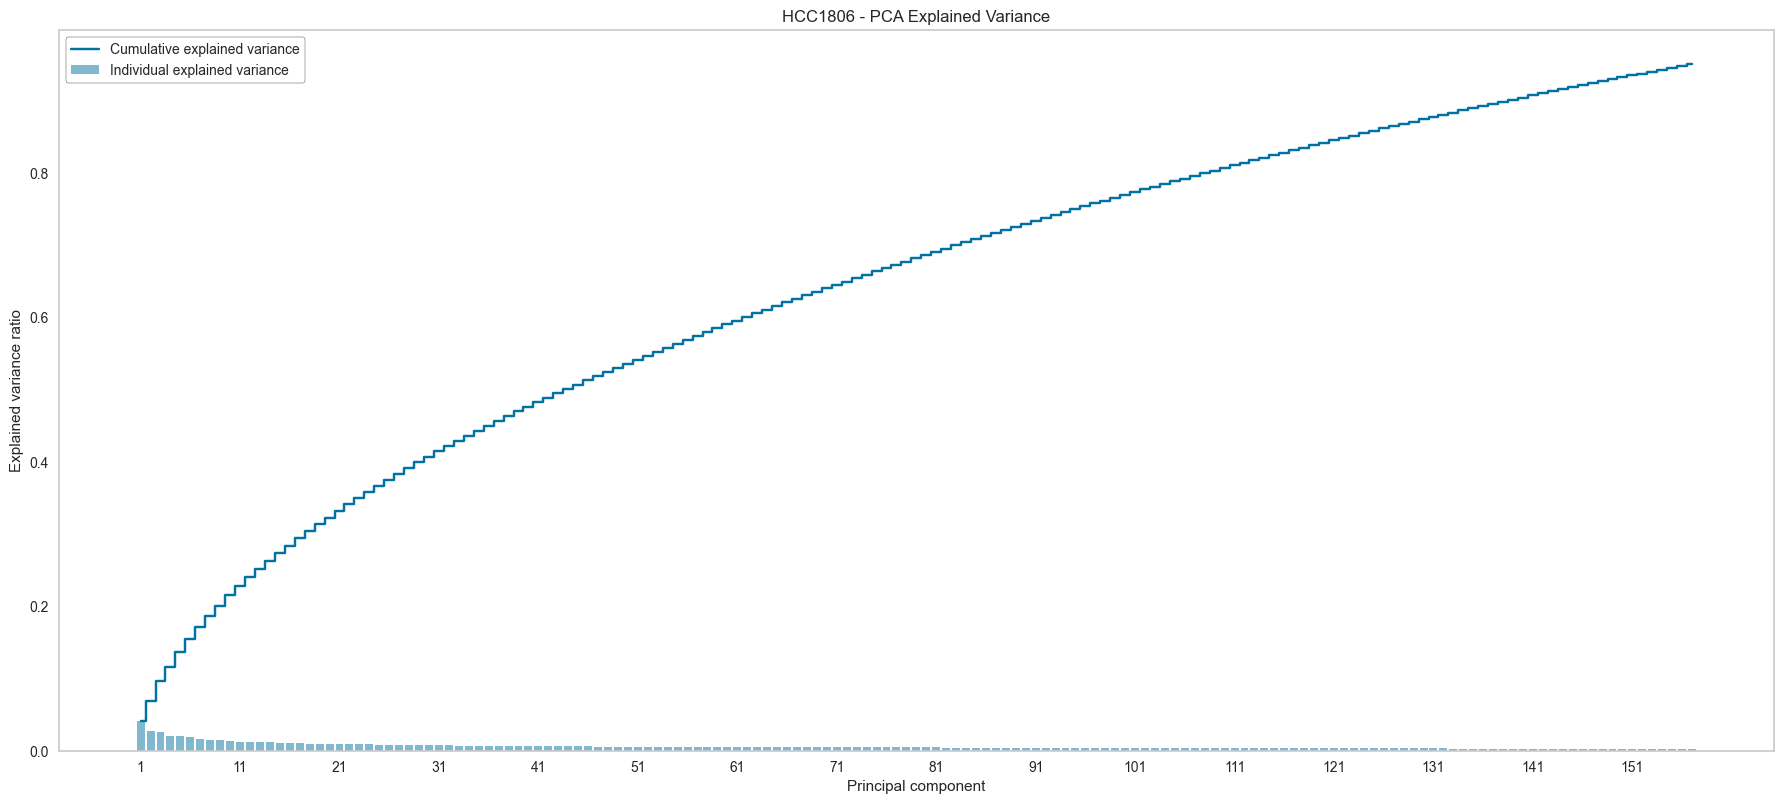

In [10]:
# Plot
exp_var_pca = PCA_HCC.explained_variance_ratio_
v = len(exp_var_pca)
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.figure(figsize=(18, 8))
plt.bar(range(1, v + 1), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, v + 1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component')
plt.xticks(range(1, v + 1, 10))
legend = plt.legend(loc='best', frameon=True)
legend.get_frame().set_edgecolor('black')
plt.tight_layout()
plt.title("HCC1806 - PCA Explained Variance")
plt.grid(visible=False)
plt.show()

The cumulative variance increases gradually across all 157 components with no sharp elbow, confirming that variance is spread evenly across many genes rather than concentrated in a few dominant directions. The individual variance of each component drops to near zero after the first few, meaning that no single component carries much information on its own.

## Visualisation in 2D

In [ ]:
# Run PCA reducing to 2 components for 2D visualisation
PCA2_HCC = PCA(n_components=2)
principalComponents_HCC2 = PCA2_HCC.fit_transform(data)

data_HCC_pr2 = pd.DataFrame(data=principalComponents_HCC2, columns=['PC1', 'PC2'])

print('Explained variation per principal component: {}'.format(PCA2_HCC.explained_variance_ratio_))

Explained variation per principal component: [0.04164704 0.02771963]


In [12]:
# Create a copy and add numeric condition labels (0 = Normo, 1 = Hypo)
n = len(data_HCC_pr2)
data_HCC_pr2_lab = data_HCC_pr2.copy()

# Map conditions to numeric values using a cleaner approach
data_HCC_pr2_lab["Condition"] = labels.map({"Normo": 0, "Hypo": 1}).values

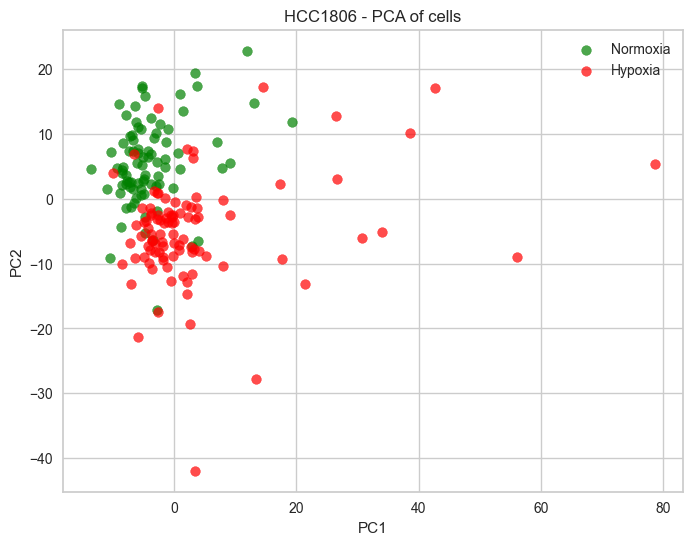

In [13]:
# Scatter plot of PC1 vs PC2 coloured by condition
plt.figure(figsize=(8, 6))

normo_mask = data_HCC_pr2_lab["Condition"] == 0
hypo_mask = data_HCC_pr2_lab["Condition"] == 1

plt.scatter(data_HCC_pr2_lab.loc[normo_mask, 'PC1'],
            data_HCC_pr2_lab.loc[normo_mask, 'PC2'],
            c='green', label='Normoxia', alpha=0.7)

plt.scatter(data_HCC_pr2_lab.loc[hypo_mask, 'PC1'],
            data_HCC_pr2_lab.loc[hypo_mask, 'PC2'],
            c='red', label='Hypoxia', alpha=0.7)

plt.title("HCC1806 - PCA of cells")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

The 2D PCA plot shows some degree of separation between the two conditions, with Normoxic cells tending to occupy the upper region and Hypoxic cells the lower region. However the boundary is not sharp and there is substantial overlap in the centre. A few outlier Hypoxic cells appear far from the main cluster with extreme PC1 values.

## Visualisation in 3D

In [14]:
# Run PCA reducing to 3 components for 3D visualisation
PCA3_HCC = PCA(n_components=3)
principalComponents_HCC3 = PCA3_HCC.fit_transform(data)

# Store result in a DataFrame with PC1, PC2, PC3 as columns
data_HCC_pr3 = pd.DataFrame(data=principalComponents_HCC3, columns=['PC1', 'PC2', 'PC3'])

print('Explained variation per principal component: {}'.format(PCA3_HCC.explained_variance_ratio_))

Explained variation per principal component: [0.04164704 0.02771957 0.02652611]


In [15]:
# Add numeric condition labels (0 = Normo, 1 = Hypo)
data_HCC_pr3_lab = data_HCC_pr3.copy()
data_HCC_pr3_lab["Condition"] = labels.map({"Normo": 0, "Hypo": 1}).values

Elevation: 20  Azimuth: 45


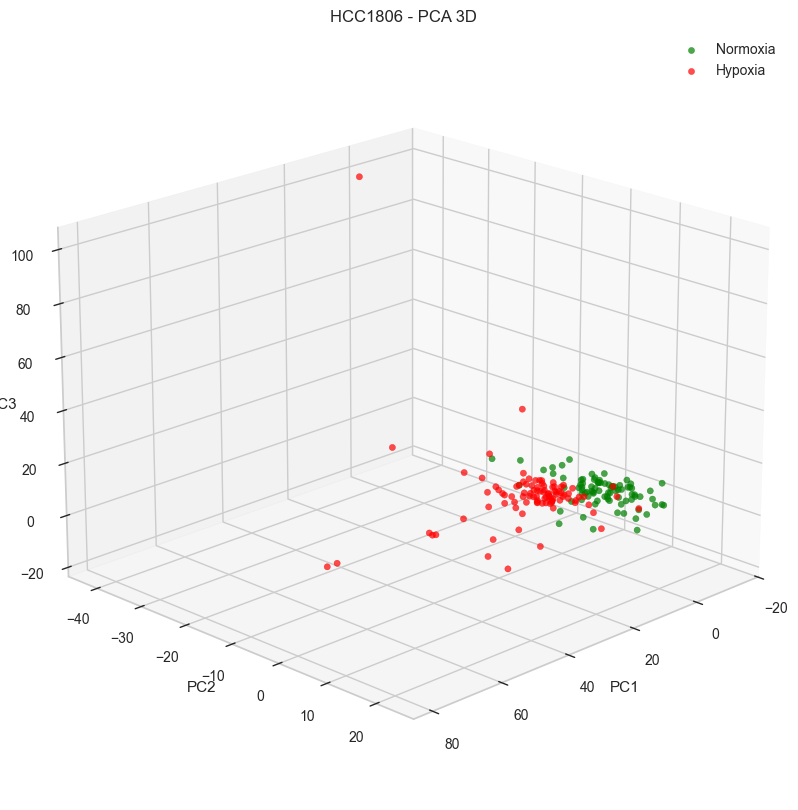

Elevation: 45  Azimuth: 135


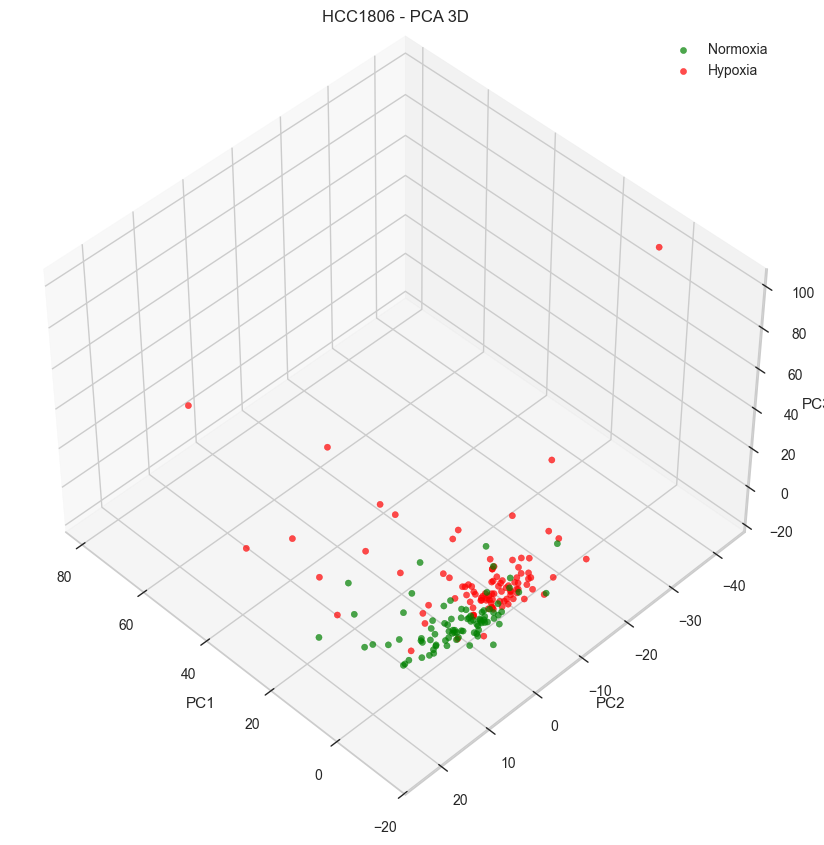

In [16]:
# Function to plot 3D PCA from different viewing angles
def PCA_3D_HCC(EL, AZ):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')

    normo_mask = data_HCC_pr3_lab["Condition"] == 0
    hypo_mask = data_HCC_pr3_lab["Condition"] == 1

    ax.scatter(data_HCC_pr3_lab.loc[normo_mask, 'PC1'],
               data_HCC_pr3_lab.loc[normo_mask, 'PC2'],
               data_HCC_pr3_lab.loc[normo_mask, 'PC3'],
               c='green', label='Normoxia', alpha=0.7)

    ax.scatter(data_HCC_pr3_lab.loc[hypo_mask, 'PC1'],
               data_HCC_pr3_lab.loc[hypo_mask, 'PC2'],
               data_HCC_pr3_lab.loc[hypo_mask, 'PC3'],
               c='red', label='Hypoxia', alpha=0.7)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('HCC1806 - PCA 3D')
    ax.legend()
    ax.view_init(elev=EL, azim=AZ)
    print("Elevation:", EL, " Azimuth:", AZ)
    plt.show()
    
# Call with different viewing angles
PCA_3D_HCC(20, 45)
PCA_3D_HCC(45, 135)

The 3D PCA plot confirms the 2D observation. The two conditions remain largely overlapping with no clean separation emerging in the third component either. The outlier Hypoxic cells are more visible from certain viewing angles, appearing well outside the main cluster. Adding PC3 does not reveal any new structure.

# 4. Clustering

We apply unsupervised clustering to the scaled data to investigate whether cells naturally group according to their biological condition without using the labels. We test two methods: K-Means and Agglomerative clustering. Both methods are run on the full scaled dataset and on the PCA-reduced 2D and 3D components. We then use UMAP to visualise the results and assess whether the clusters found correspond to the true Hypoxic and Normoxic conditions.

## K-Means

### Choosing the numebr of clusters

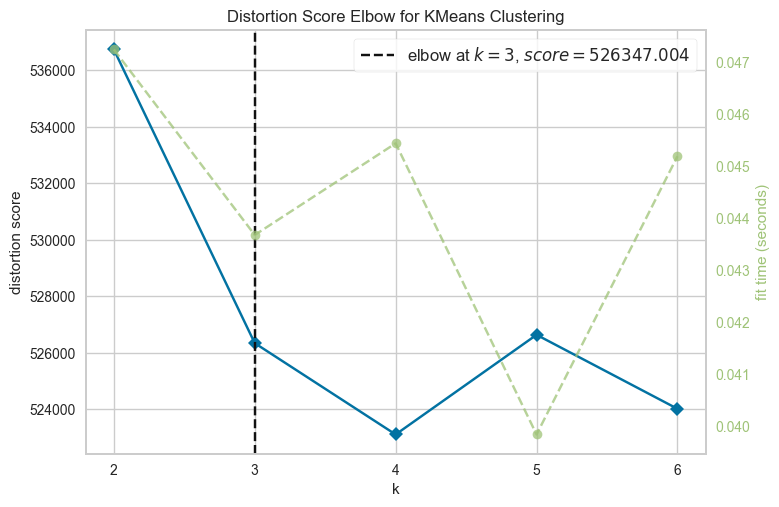

In [49]:
# Elbow method
from yellowbrick.cluster import KElbowVisualizer

fig, ax = plt.subplots()
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,7), ax=ax)
visualizer.fit(data)
ax.set_xticks(range(2, 7))
visualizer.show()
plt.show()

The distortion score measures the sum of squared distances between each cell and its assigned cluster centroid. As K increases the score decreases since smaller clusters are naturally more compact, so we look for the point where further increasing K stops giving meaningful improvement.

The KElbowVisualizer detects the elbow at K=3, where the curve bends most sharply, suggesting that K=3 provides a more natural partition than K=2 on the scaled data. This is plausible since cells are highly complex multivariable systems. We nonetheless proceed with K=2 as our primary analysis given the biological expectation of two conditions, treating K=3 
as a secondary exploration.

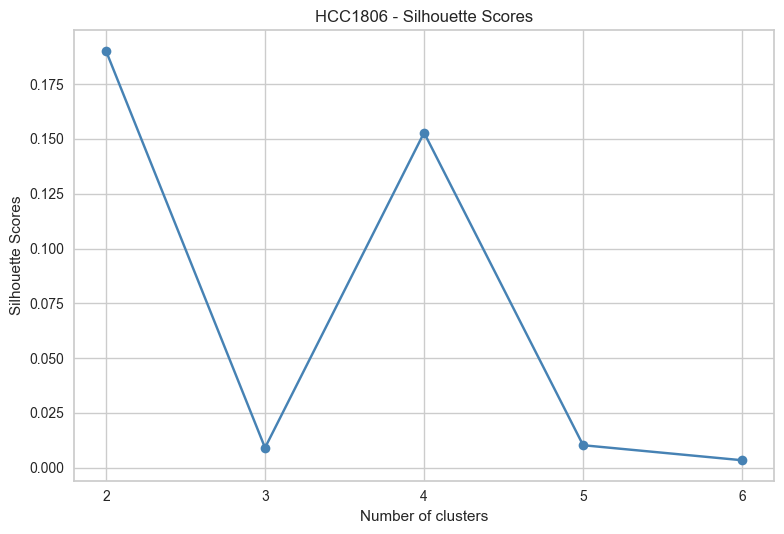

[(2, np.float64(0.19)), (3, np.float64(0.009)), (4, np.float64(0.153)), (5, np.float64(0.01)), (6, np.float64(0.003))]


In [18]:
# Silhouette score
silhouette_scores = []

k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, max_iter=500, tol=1e-04,
                init='k-means++', n_init=20, random_state=42)
    km.fit(data)
    silhouette_scores.append(silhouette_score(data, km.labels_))

fig, ax = plt.subplots()
ax.plot(k_values, silhouette_scores, marker='o', color='steelblue')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette Scores')
ax.set_title('HCC1806 - Silhouette Scores')
plt.title('HCC1806 - Silhouette Scores')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print(list(zip(k_values, [round(s, 3) for s in silhouette_scores])))

### Silhouette Analysis Diagrams

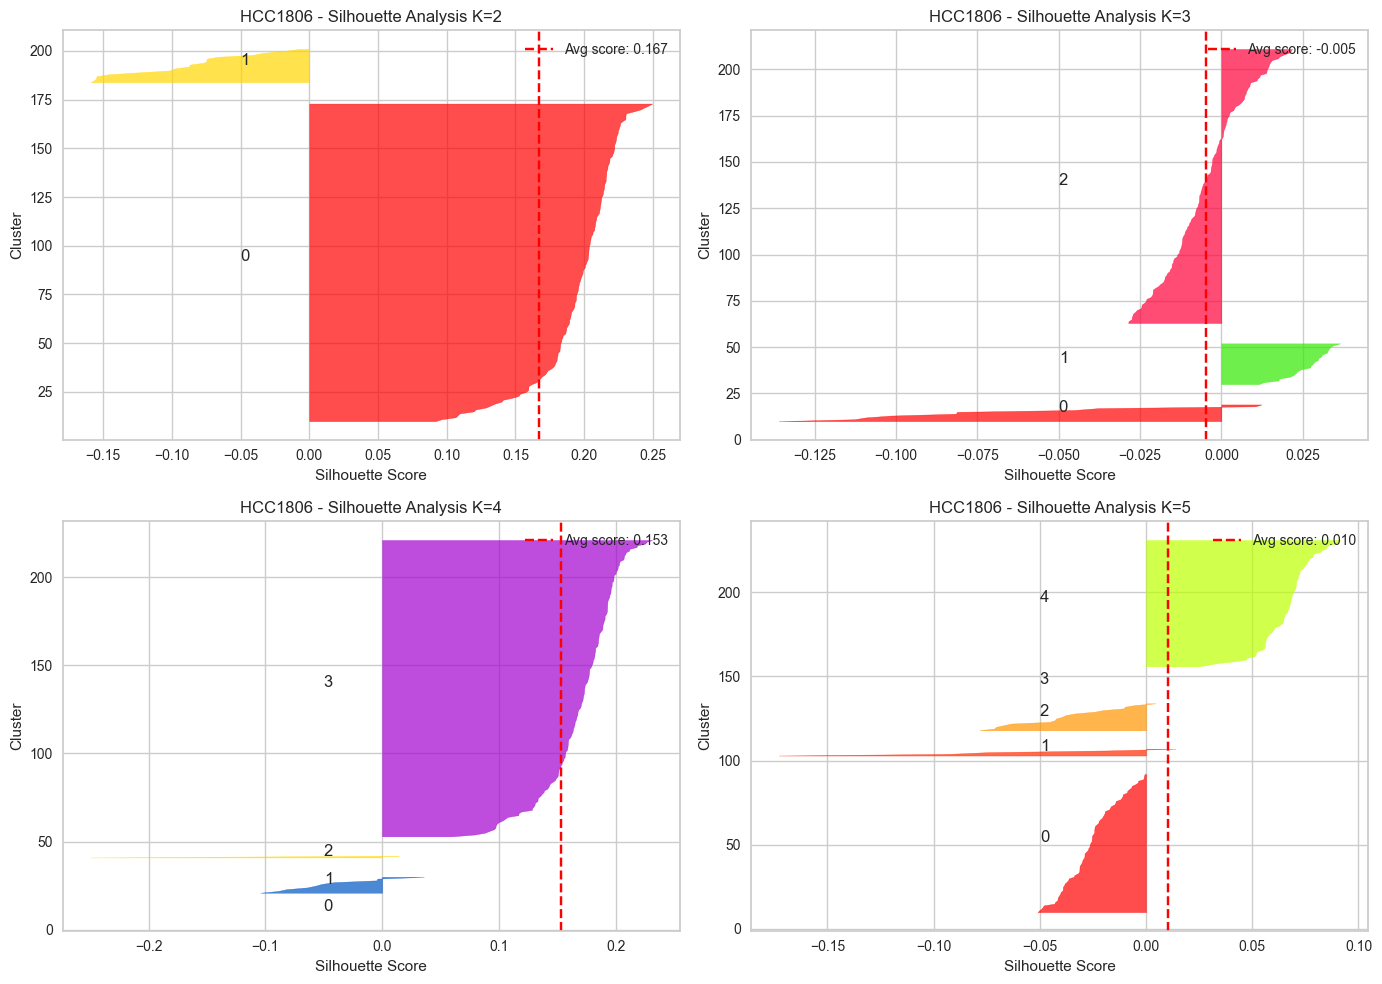

In [19]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k in enumerate(range(2, 6)):
    ax = axes[idx]
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data)
    
    # Compute silhouette score for each cell
    sample_silhouette_values = silhouette_samples(data, cluster_labels)
    avg_score = silhouette_score(data, cluster_labels)
    
    y_lower = 10
    for i in range(k):
        # Get silhouette scores for cluster i and sort them
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()
        
        size = len(ith_cluster_values)
        y_upper = y_lower + size
        
        color = cm.prism(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, color=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10
    
    # Draw average silhouette score line
    ax.axvline(x=avg_score, color="red", linestyle="--", label=f'Avg score: {avg_score:.3f}')
    ax.set_title(f'HCC1806 - Silhouette Analysis K={k}')
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Cluster')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [20]:
# Check cluster sizes for each K
for k in range(2, 7):
    km = KMeans(n_clusters=k, max_iter=500, tol=1e-04,
                init='k-means++', n_init=20, random_state=42)
    km.fit(data)
    counts = pd.Series(km.labels_).value_counts().sort_index()
    score = silhouette_score(data, km.labels_)
    print(f"K={k} | Score: {score:.3f} | Cluster sizes: {counts.values}")

K=2 | Score: 0.190 | Cluster sizes: [ 11 171]
K=3 | Score: 0.009 | Cluster sizes: [ 30 136  16]
K=4 | Score: 0.153 | Cluster sizes: [  1  10   2 169]
K=5 | Score: 0.010 | Cluster sizes: [83  5 17  1 76]
K=6 | Score: 0.003 | Cluster sizes: [35  1 77 58  1 10]


The silhouette scores and analysis diagrams reveal a fundamental problem with clustering directly in 3000-dimensional space. Despite K=2 achieving the highest score (0.190), the corresponding cluster sizes (11 and 171) show that this score is driven by one dominant cluster containing nearly all cells, with a small outlier group isolated on the side. The same pattern repeats at K=4, where 169 out of 182 cells collapse into a single cluster. This is possibly because in very high dimensional spaces, pairwise distances between cells can 
approximately equal after scaling, making it hard for K-Means to find meaningful boundaries. 

This motivates later running clustering on the PCA- educed space rather than the full 3000 dimensions, retaining only the components that carry meaningful variance.

### K=2 Clustering

In [21]:
# Run K-Means with K=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_2.fit(data)

print("Cluster counts:")
print(pd.Series(kmeans_2.labels_).value_counts())

Cluster counts:
0    164
1     18
Name: count, dtype: int64


K-Means assigned 164 cells to Cluster 0 and 18 to Cluster 1. This is a heavily imbalanced split, since we know from the EDA that we have 97 hypoxic and 85 normoxic cells.

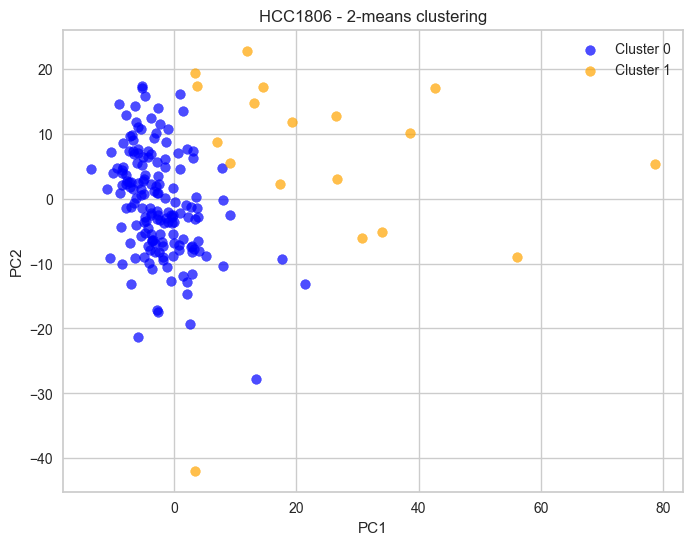

In [22]:
# 2D scatter plot coloured by K-Means K=2 cluster labels
plt.figure(figsize=(8, 6))

cluster0_mask = kmeans_2.labels_ == 0
cluster1_mask = kmeans_2.labels_ == 1

plt.scatter(data_HCC_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.7)

plt.scatter(data_HCC_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 - 2-means clustering')
plt.legend()
plt.show()

The 2D PCA plot shows a heavily imbalanced split. Cluster 0 (blue) contains 164 cells while Cluster 1 (orange) contains only 18, all of which appear as outliers with high PC1 values. K-Means is essentially separating a small group of extreme cells from the main mass rather than finding any biologically meaningful boundary.

It is worth noting that PC1 and PC2 capture only ~7% of the total variance, so this plot is an incomplete picture of the space where K-Means actually operated. The cluster separation may look different in the full high-dimensional space, making this visualisation potentially misleading on its own.

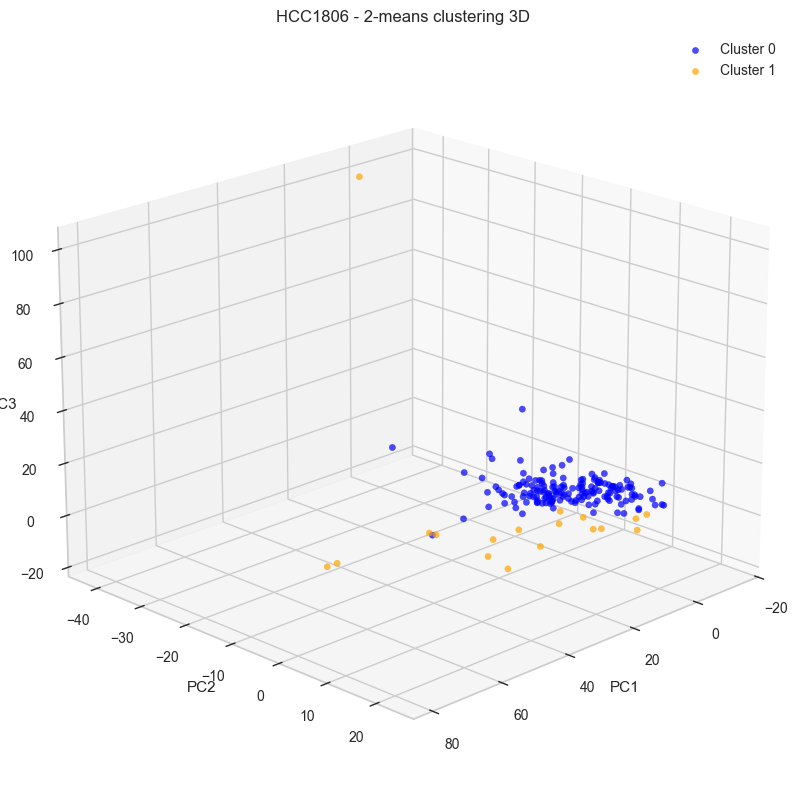

In [23]:
# 3D scatter plot coloured by K-Means K=2 cluster labels
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

cluster0_mask = kmeans_2.labels_ == 0
cluster1_mask = kmeans_2.labels_ == 1

ax.scatter(data_HCC_pr3_lab.loc[cluster0_mask, 'PC1'],
           data_HCC_pr3_lab.loc[cluster0_mask, 'PC2'],
           data_HCC_pr3_lab.loc[cluster0_mask, 'PC3'],
           c='blue', label='Cluster 0', alpha=0.7)

ax.scatter(data_HCC_pr3_lab.loc[cluster1_mask, 'PC1'],
           data_HCC_pr3_lab.loc[cluster1_mask, 'PC2'],
           data_HCC_pr3_lab.loc[cluster1_mask, 'PC3'],
           c='orange', label='Cluster 1', alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('HCC1806 - 2-means clustering 3D')
ax.legend()
ax.view_init(elev=20, azim=45)
plt.show()

The 3D plot confirms the same picture. The 18 orange cells are scattered as outliers across the PC1 axis while the 164 blue cells form the main compact mass. Adding PC3 does not reveal any new structure and the degenerate nature of the clustering remains unchanged.

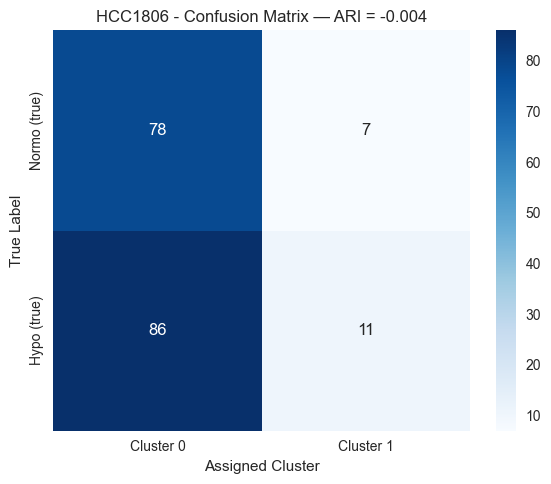

Adjusted Rand Index: -0.004


In [24]:
# Confusion matrix
true_numeric = (pd.Series(data_HCC_pr2_lab["Condition"].values) == 1).astype(int).values
ari = adjusted_rand_score(true_numeric, kmeans_2.labels_)
cm = confusion_matrix(true_numeric, kmeans_2.labels_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Normo (true)', 'Hypo (true)'])
plt.title(f'HCC1806 - Confusion Matrix — ARI = {ari:.3f}')
plt.ylabel('True Label')
plt.xlabel('Assigned Cluster')
plt.tight_layout()
plt.show()

print(f"Adjusted Rand Index: {ari:.3f}")

The confusion matrix confirms the degenerate clustering. Cluster 0 contains 78 Normoxic and 86 Hypoxic cells, while Cluster 1 contains only 7 Normoxic and 11 Hypoxic cells. Both clusters have roughly the same proportion of Hypo and Normo cells (~53% Hypo), meaning neither maps to a biological condition. The ARI of -0.004 is essentially zero, confirming the assignment is no better than random.

In [25]:
# Clustering accuracy function
def clustering_accuracy(clust_labels, og_labels):
    print("Clustering accuracy:",
          max(np.count_nonzero(clust_labels == og_labels) * 100 / len(og_labels),
              100 - np.count_nonzero(clust_labels == og_labels) * 100 / len(og_labels)),
          "%")

og_labels = data_HCC_pr2_lab["Condition"].values
clustering_accuracy(kmeans_2.labels_, og_labels)

Clustering accuracy: 51.0989010989011 %


The clustering accuracy of 51.1% is consistent with the ARI result and essentially equivalent to random guessing. K-Means on the full 3000 dimensional space fails entirely to recover the biological separation between Hypoxic and Normoxic cells.

In [26]:
def diagnoses(kmeans_model, data):
    n_clusters = kmeans_model.n_clusters
    labels = kmeans_model.labels_
    centers = kmeans_model.cluster_centers_

    cardinality = [np.sum(labels == i) for i in range(n_clusters)]

    magnitude = []
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        distances = np.linalg.norm(cluster_points - centers[i], axis=1)
        magnitude.append(np.sum(distances))

    bar_colors = ['#e74c3c', '#3498db', '#2ecc71'][:n_clusters]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].bar(range(n_clusters), cardinality, color=bar_colors)
    axes[0].set_xlabel('Cluster Label')
    axes[0].set_ylabel('Points in Cluster')
    axes[0].set_title('Cardinality')
    axes[0].set_xticks(range(n_clusters))

    axes[1].bar(range(n_clusters), magnitude, color=bar_colors)
    axes[1].set_xlabel('Cluster Label')
    axes[1].set_ylabel('Total Point-to-Centroid Distance')
    axes[1].set_title('Magnitude')
    axes[1].set_xticks(range(n_clusters))

    plt.tight_layout()
    plt.show()

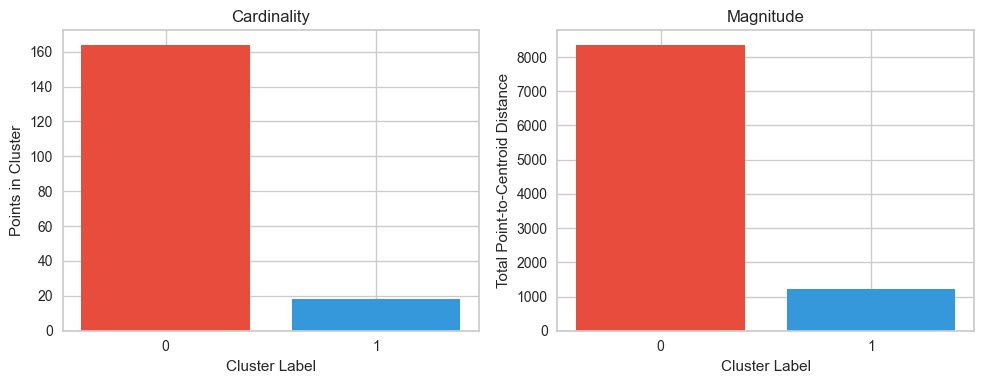

In [27]:
diagnoses(kmeans_2, data.values)

The cardinality plot is a further confirmation of the class imbalanced split of k=2 means clustering

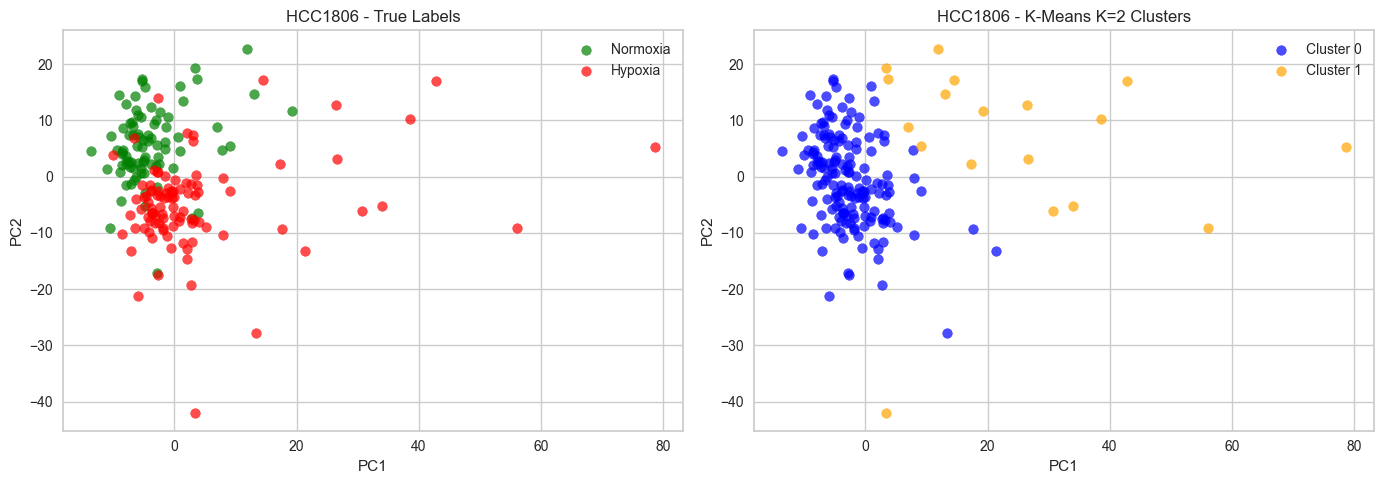

In [28]:
# Side by side comparison — true labels vs K-Means K=2 clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
normo_mask = data_HCC_pr2_lab["Condition"] == 0
hypo_mask = data_HCC_pr2_lab["Condition"] == 1

axes[0].scatter(data_HCC_pr2_lab.loc[normo_mask, 'PC1'],
                data_HCC_pr2_lab.loc[normo_mask, 'PC2'],
                c='green', label='Normoxia', alpha=0.7)
axes[0].scatter(data_HCC_pr2_lab.loc[hypo_mask, 'PC1'],
                data_HCC_pr2_lab.loc[hypo_mask, 'PC2'],
                c='red', label='Hypoxia', alpha=0.7)
axes[0].set_title('HCC1806 - True Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# K-Means clusters
cluster0_mask = kmeans_2.labels_ == 0
cluster1_mask = kmeans_2.labels_ == 1

axes[1].scatter(data_HCC_pr2_lab.loc[cluster0_mask, 'PC1'],
                data_HCC_pr2_lab.loc[cluster0_mask, 'PC2'],
                c='blue', label='Cluster 0', alpha=0.7)
axes[1].scatter(data_HCC_pr2_lab.loc[cluster1_mask, 'PC1'],
                data_HCC_pr2_lab.loc[cluster1_mask, 'PC2'],
                c='orange', label='Cluster 1', alpha=0.7)
axes[1].set_title('HCC1806 - K-Means K=2 Clusters')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

The side by side comparison is the most revealing plot. The true labels show red and green partially overlapping with some suggestion of a horizontal separation along PC2, while the K-Means plot shows a completely different pattern. A compact orange cluster of outlier cells is isolated on the right and the remaining 164 blue cells are grouped together on the left. K-Means is likely finding a geometric grouping driven by outlier cells with extreme PC1 
values, which is unrelated to the biological condition.

### K=3 Clustering

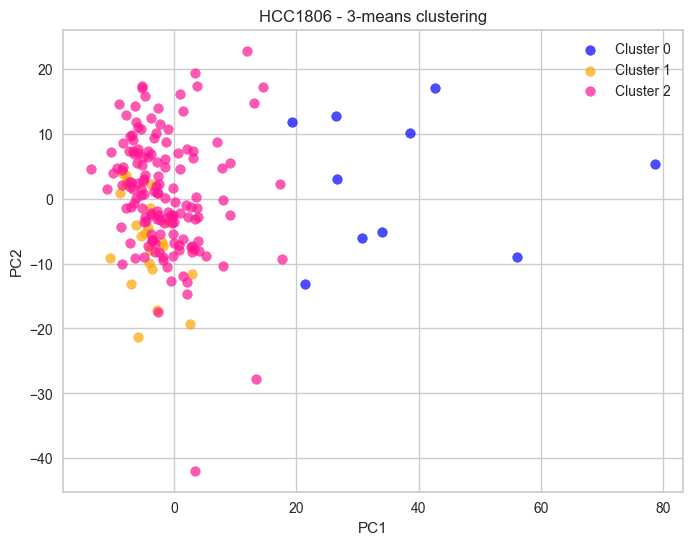

In [29]:
# Run K-Means with K=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(data)

# 2D scatter plot coloured by K=3 cluster labels
plt.figure(figsize=(8, 6))

cluster0_mask = kmeans_3.labels_ == 0
cluster1_mask = kmeans_3.labels_ == 1
cluster2_mask = kmeans_3.labels_ == 2

plt.scatter(data_HCC_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.7)

plt.scatter(data_HCC_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.7)

plt.scatter(data_HCC_pr2_lab.loc[cluster2_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster2_mask, 'PC2'],
            c='deeppink', label='Cluster 2', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 - 3-means clustering')
plt.legend()
plt.show()

In [30]:
def clustering_accuracy(clust_labels, og_labels):
    clust_labels = np.array(clust_labels)
    og_labels = np.array(og_labels)
    mapped = np.zeros_like(clust_labels)
    for cluster in np.unique(clust_labels):
        mask = clust_labels == cluster
        mapped[mask] = np.bincount(og_labels[mask]).argmax()
    acc = np.mean(mapped == og_labels) * 100
    print(f"Clustering accuracy: {acc:.2f} %")

clustering_accuracy(kmeans_3.labels_, og_labels)

Clustering accuracy: 53.85 %


K=3 produces an even more fragmented partition. The main mass is split between Cluster 2 (pink) and Cluster 1 (orange) while Cluster 0 (blue) again isolates the high PC1 outliers. The clustering accuracy of 53.85% is virtually identical to K=2 (51.1%), so this cannot be considered an improvement. It is possible that the presence of extreme outlier cells is distracting the algorithm from finding the true biological boundary, and that better outlier handling could lead to more meaningful partitions.

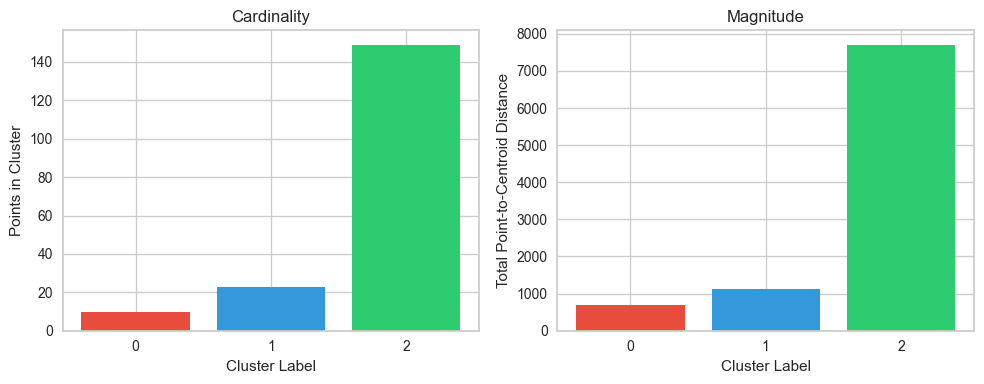

In [31]:
diagnoses(kmeans_3, data.values)

The cardinality and magnitude plots further confirm the imbalanced partition. Cluster 2 dominates with ~147 cells while Clusters 0 and 1 contain only ~11 and ~24 cells respectively. Rather than finding three meaningful groups, K-Means has collapsed most cells into one dominant partition while isolating two small outlier groups.

## Agglomerative Clustering

In [ ]:
# Run agglomerative clustering
agglomerative = AgglomerativeClustering(n_clusters=2, linkage='ward', compute_distances=True)
agglomerative.fit(data)

print("Cluster counts:")
print(pd.Series(agglomerative.labels_).value_counts())

Cluster counts:
0    163
1     19
Name: count, dtype: int64


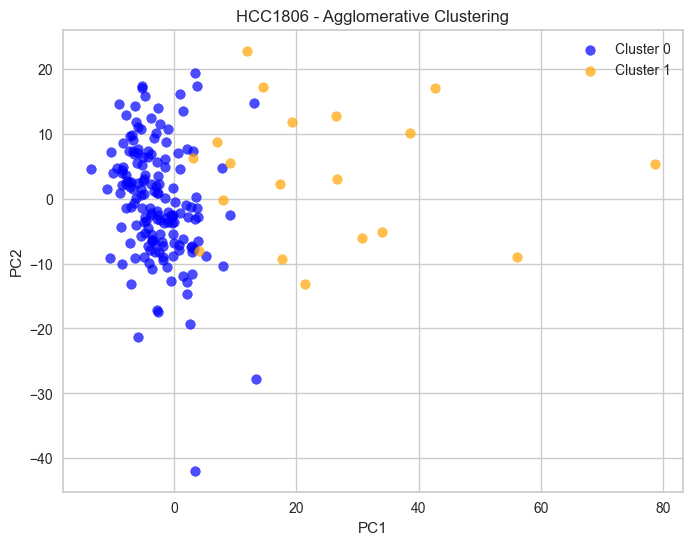

In [ ]:
# 2D plot
plt.figure(figsize=(8, 6))

cluster0_mask = agglomerative.labels_ == 0
cluster1_mask = agglomerative.labels_ == 1

plt.scatter(data_HCC_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.7)

plt.scatter(data_HCC_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 - Agglomerative Clustering')
plt.legend()
plt.show()

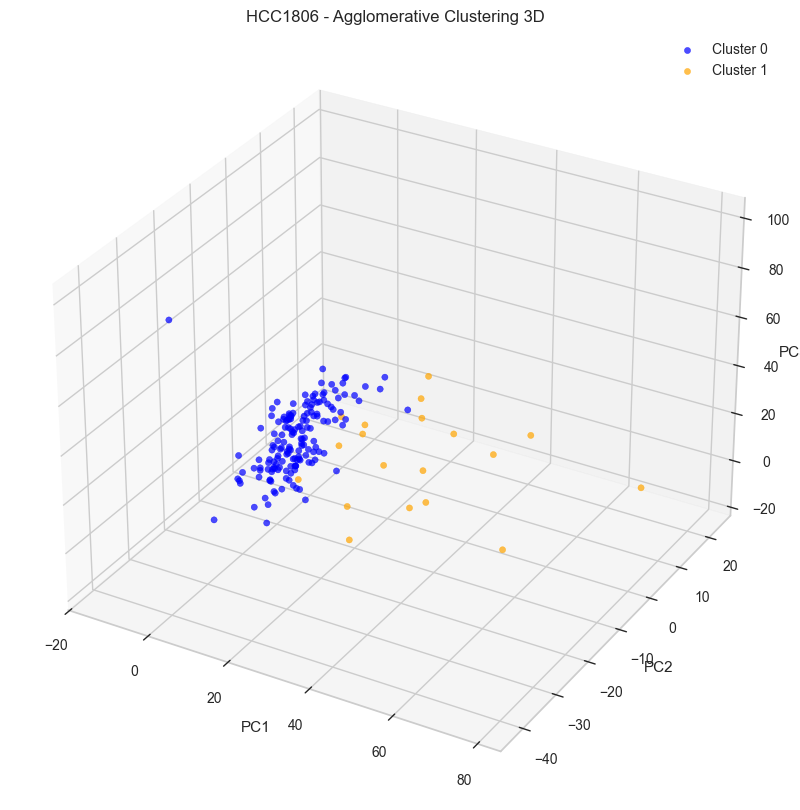

In [ ]:
# 3D plot 
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

cluster0_mask = agglomerative.labels_ == 0
cluster1_mask = agglomerative.labels_ == 1

ax.scatter(data_HCC_pr3_lab.loc[cluster0_mask, 'PC1'],
           data_HCC_pr3_lab.loc[cluster0_mask, 'PC2'],
           data_HCC_pr3_lab.loc[cluster0_mask, 'PC3'],
           c='blue', label='Cluster 0', alpha=0.7)

ax.scatter(data_HCC_pr3_lab.loc[cluster1_mask, 'PC1'],
           data_HCC_pr3_lab.loc[cluster1_mask, 'PC2'],
           data_HCC_pr3_lab.loc[cluster1_mask, 'PC3'],
           c='orange', label='Cluster 1', alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('HCC1806 - Agglomerative Clustering 3D')
ax.legend()
plt.show()

### Clustering Accuracy

In [35]:
# Clustering accuracy
agg_predict = agglomerative.labels_
clustering_accuracy(agg_predict, og_labels)

Clustering accuracy: 53.30 %


Agglomerative clustering produces a similarly imbalanced result, with 163 cells in Cluster 0 and only 19 in Cluster 1. The 2D and 3D plots show the same pattern as K-Means, with the orange cluster isolating outlier cells while the main mass remains undifferentiated. The 
clustering accuracy of 53.30% is virtually identical to K-Means (51.1%), confirming that the dimensionality problem affects agglomerative clustering as well.

### Dendogram

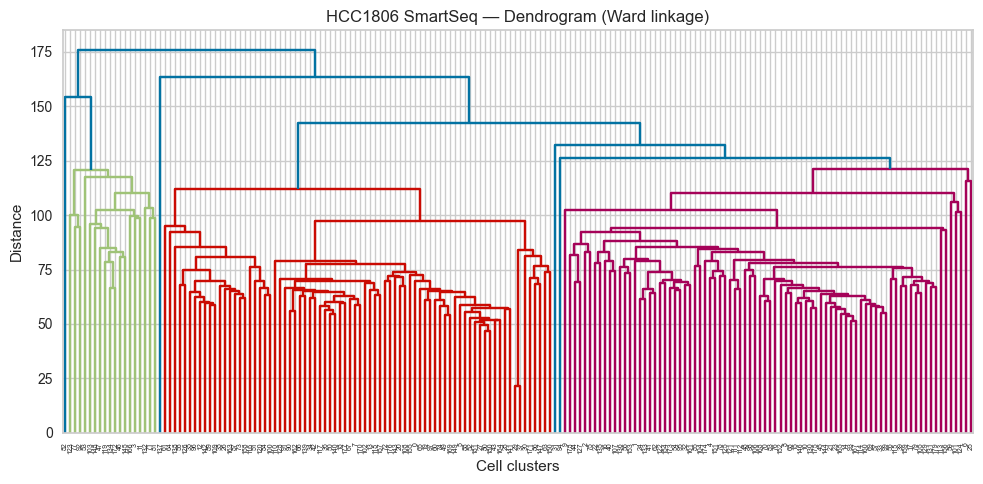

In [36]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10, 5))
dendrogram(np.column_stack([agglomerative.children_, 
                             agglomerative.distances_, 
                             np.zeros(len(agglomerative.distances_))]).astype(float))
plt.title('HCC1806 SmartSeq — Dendrogram (Ward linkage)')
plt.xlabel('Cell clusters')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

The dendrogram records the entire merging history. Cells that are similar merge early, low on the y-axis, while dissimilar groups merge late (high on the y-axis). The y axis represents the distance between merged groups in gene expression space. Three main colour groups are visible, merging at progressively higher distances, with the final merge occurring at around 175. Despite the algorithm finding structurally distinct groups, the clustering accuracy of 53.30% confirms these groups unlikely correspond to the biological hypoxic and normoxic conditions.

### Clustering of principal components

We run agglomerative clustering on the first 2 and 3 principal components. Both K Means and agglomerative performed poorly on the full dataset, but it is worth testing whether the reduced PCA space changes the outcome.

**agglomerative clustering on 2D PCA components**

In [37]:
# Agglomerative clustering on 2D PCA components
agg_PC2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_PC2.fit(data_HCC_pr2)

print("Cluster counts:")
print(pd.Series(agg_PC2.labels_).value_counts())

Cluster counts:
0    167
1     15
Name: count, dtype: int64


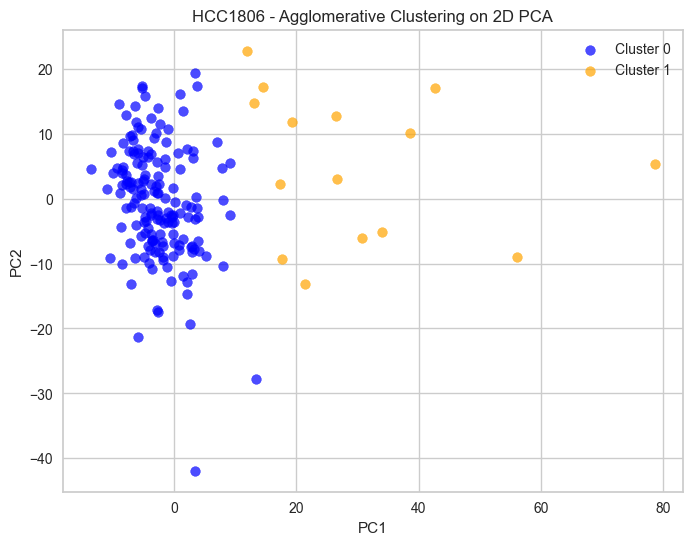

In [ ]:
# 2D plot
plt.figure(figsize=(8, 6))

cluster0_mask = agg_PC2.labels_ == 0
cluster1_mask = agg_PC2.labels_ == 1

plt.scatter(data_HCC_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.7)

plt.scatter(data_HCC_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_HCC_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 - Agglomerative Clustering on 2D PCA')
plt.legend()
plt.show()


In [39]:
clustering_accuracy(agg_PC2.labels_, og_labels)

Clustering accuracy: 53.30 %


**agglomerative clustering on 3D PCA components**

In [40]:
# Agglomerative clustering on 3D PCA components
agg_PC3 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_PC3.fit(data_HCC_pr3)

print("Cluster counts:")
print(pd.Series(agg_PC3.labels_).value_counts())


Cluster counts:
0    167
1     15
Name: count, dtype: int64


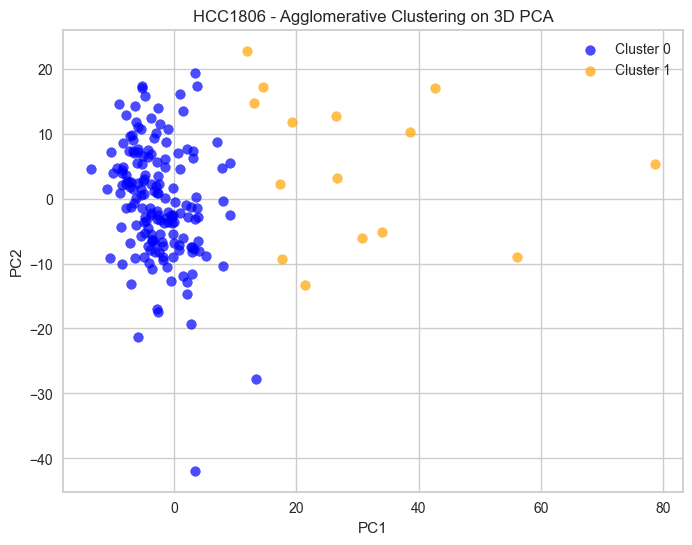

In [41]:
# 2D scatter plot
plt.figure(figsize=(8, 6))

cluster0_mask = agg_PC3.labels_ == 0
cluster1_mask = agg_PC3.labels_ == 1

plt.scatter(data_HCC_pr3_lab.loc[cluster0_mask, 'PC1'],
            data_HCC_pr3_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.7)

plt.scatter(data_HCC_pr3_lab.loc[cluster1_mask, 'PC1'],
            data_HCC_pr3_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 - Agglomerative Clustering on 3D PCA')
plt.legend()
plt.show()

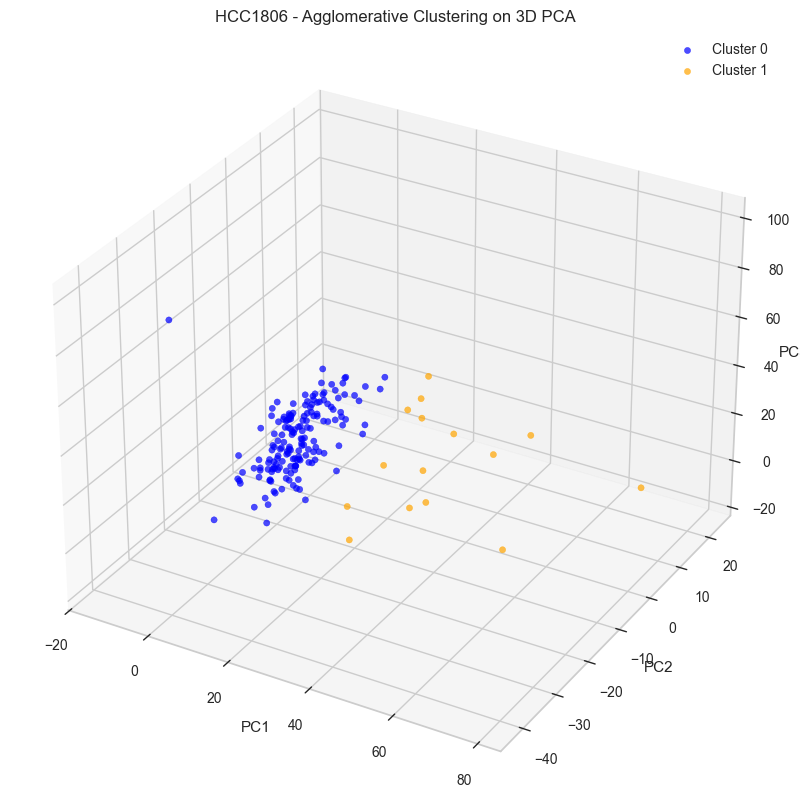

In [42]:
# 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

cluster0_mask = agg_PC3.labels_ == 0
cluster1_mask = agg_PC3.labels_ == 1

ax.scatter(data_HCC_pr3_lab.loc[cluster0_mask, 'PC1'],
           data_HCC_pr3_lab.loc[cluster0_mask, 'PC2'],
           data_HCC_pr3_lab.loc[cluster0_mask, 'PC3'],
           c='blue', label='Cluster 0', alpha=0.7)

ax.scatter(data_HCC_pr3_lab.loc[cluster1_mask, 'PC1'],
           data_HCC_pr3_lab.loc[cluster1_mask, 'PC2'],
           data_HCC_pr3_lab.loc[cluster1_mask, 'PC3'],
           c='orange', label='Cluster 1', alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('HCC1806 - Agglomerative Clustering on 3D PCA')
ax.legend()
plt.show()

In [43]:
clustering_accuracy(agg_PC3.labels_, og_labels)

Clustering accuracy: 53.30 %


Agglomerative clustering on both the 2D and 3D PCA components gives the same accuracy of 53.30%, identical to the full dataset result. The plots show the same identical pattern. Reducing to 2 or 3 principal components, which together capture only ~7% of the total variance, provides no additional structure for the algorithm to work with and yields no improvement over clustering in the full space.

## UMAP 

UMAP is a nonlinear dimensionality reduction technique that preserves the local neighbourhood structure of the data, allowing us to visualise high dimensional gene expression data in 2D. Unlike PCA, UMAP can capture non linear relationships between cells, making it particularly useful when linear methods fail to reveal structure.

We use UMAP purely as a visualisation tool. Rather than running new clustering on the UMAP embedding, we project the cluster assignments already found by K-Means onto the UMAP space. This allows us to assess whether the clusters correspond to any meaningful structure in the data and whether UMAP reveals a separation between hypoxic and normoxic cells that the clustering methods failed to find.

In [ ]:
# Run UMAP to reduce to 2 dimensions
# note that data is already scaled (StandardScaler applied at preprocessing step)
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=50, random_state=42)
embedding = reducer.fit_transform(data)

# Store result in a DataFrame
data_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])

print("UMAP embedding shape:", data_umap.shape)
data_umap.head()

/Users/Giuly/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (182, 2)


,UMAP1,UMAP2
0,10.913190,9.767106
1,10.826175,8.305948
2,11.321043,8.161730
3,11.165845,8.403736
4,11.016431,7.611860


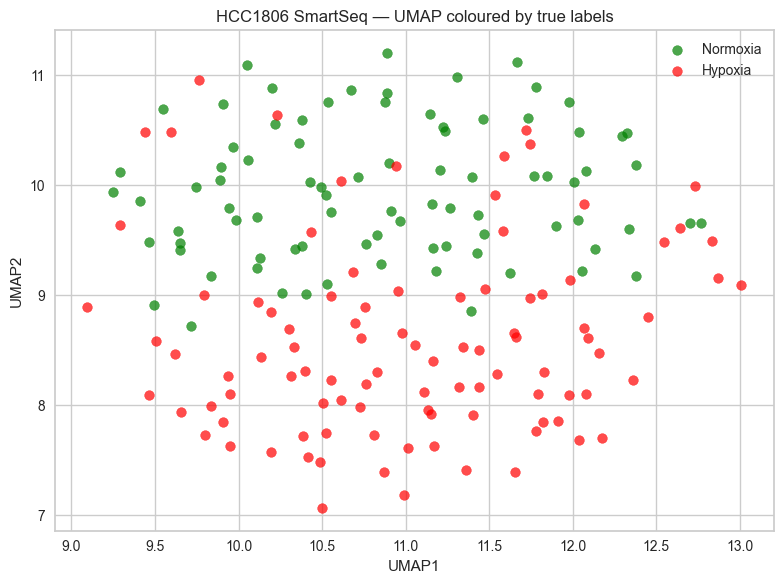

In [45]:
# Plot UMAP coloured by true labels
plt.figure(figsize=(8, 6))

normo_mask = data_HCC_pr2_lab['Condition'] == 0
hypo_mask = data_HCC_pr2_lab['Condition'] == 1

plt.scatter(data_umap.loc[normo_mask, 'UMAP1'], data_umap.loc[normo_mask, 'UMAP2'],
            c='green', label='Normoxia', alpha=0.7)
plt.scatter(data_umap.loc[hypo_mask, 'UMAP1'], data_umap.loc[hypo_mask, 'UMAP2'],
            c='red', label='Hypoxia', alpha=0.7)

plt.title('HCC1806 SmartSeq — UMAP coloured by true labels')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.tight_layout()
plt.show()

The UMAP embedding reveals a clearer spatial separation between Hypoxic and Normoxic cells than PCA. Normoxic cells (green) cluster predominantly in the upper half of the space while Hypoxic cells (red) occupy the lower half, with some overlap in the middle. PCA showed a similar vertical tendency but the boundary was much less defined. This further suggests that the hypoxia signal in HCC1806 has a non linear component that UMAP is better able to capture.

###  Plot K-Means K=2 clusters on UMAP

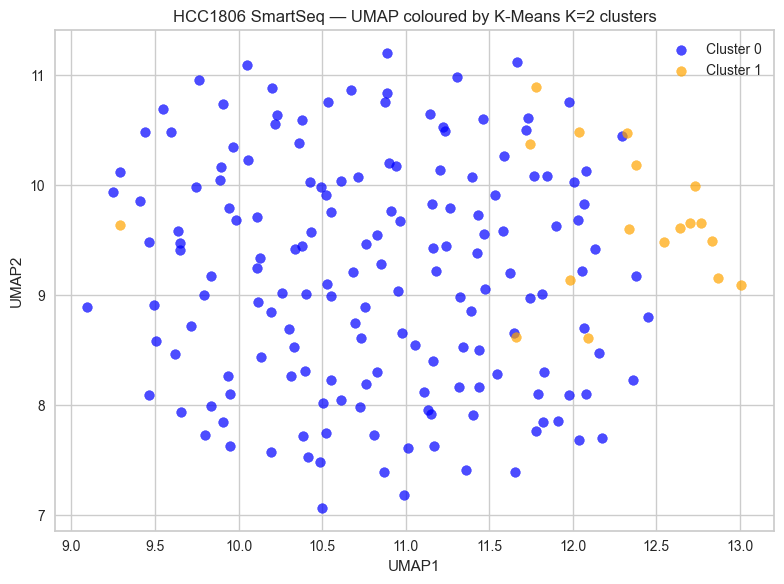

In [ ]:
plt.figure(figsize=(8, 6))
for cluster, color, label in [(0, 'blue', 'Cluster 0'), (1, 'orange', 'Cluster 1')]:
    mask = kmeans_2.labels_ == cluster
    plt.scatter(data_umap.loc[mask, 'UMAP1'], data_umap.loc[mask, 'UMAP2'],
                c=color, label=label, alpha=0.7)
plt.title('HCC1806 SmartSeq — UMAP coloured by K-Means K=2 clusters')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.tight_layout()
plt.show()

Projecting the K-Means clusters onto the UMAP does not yield any improvement. The orange cells are scattered across the embedding with no coherent structure, and one Cluster 1 cell appears completely isolated from the rest, further confirming that K-Means failed to find any meaningful partition in this dataset

# Conclusion


This analysis applied PCA, K-Means, Agglomerative clustering, and UMAP to the HCC1806 SMARTseq dataset to investigate whether unsupervised methods could recover the biological separation between hypoxic and normoxic cells.

PCA required 157 components to explain 95% of the variance, reflecting the biological complexity of the system where no single gene dominates the variance. Both the 2D and 3D projections showed partial separation between the two conditions, with normoxic cells tending to occupy the upper region and hypoxic cells the lower region, though without a sharp boundary.

Clustering was largely unsuccessful across all methods. K-Means on the full dataset achieved only 51.1% accuracy, equivalent to random guessing, due to high dimensionality, causing degenerate partitions dominated by outlier cells. Agglomerative clustering performed similarly at 53.30%. Reducing to 2 and 3 PCA components did not improve results, yielding 
comparable accuracies in both cases. UMAP revealed a clearer separation between the two conditions than PCA, suggesting the hypoxia signal has a non linear component, but even this could not be exploited by unsupervised methods alone.

In hindsight, the presence of outlier cells likely misled the clustering algorithms, and more careful outlier handling could have improved results. That said, the fundamental difficulty here is biological: cells are highly complex systems and compressing 3000 
dimensional gene expression data into two groups is not simple, particularly without label information.

Given that unsupervised clustering failed to reliably separate the two conditions, we proceed with supervised learning on the provided filtered normalised dataset (separate notebook). The partial separation visible in both PCA and UMAP suggests the biological signal is present in the data, and a supervised classifier with access to the true labels should be able to learn this boundary more effectively.